# Alert Correlation & Dedup Engine — Proof of Concept
**Synergy 2026 · HPE Problem Statement #10 · Round 1 Initial Progress**

One infrastructure failure triggers hundreds of downstream alerts. This PoC proves our core pipeline end-to-end on realistic synthetic data:

**raw alert flood → deduplication → semantic + temporal clustering → root-cause pick → Escalation Risk Score → Alert DNA match**

Every synthetic alert carries a hidden `ground_truth` label the pipeline never sees, so the evaluation numbers at the end are measured, not claimed.

In [1]:
import os, sys, warnings
os.environ["USE_TF"] = "0"          # skip TensorFlow import path in transformers
warnings.filterwarnings("ignore")
sys.path.insert(0, "../backend")
sys.path.insert(0, "../data")

import json
import numpy as np
import pandas as pd

## 1 · Generate a realistic alert flood
Three cascading incidents (root cause + downstream symptoms, with monitoring re-fires) plus routine background noise, spread over a 45-minute window.

In [2]:
from synthetic_alert_generator import generate_batch

SEED = 7
alerts = generate_batch(n_incidents=3, n_noise=20, window_minutes=45, seed=SEED)
print(f"{len(alerts)} raw alerts")
pd.DataFrame(alerts)[["timestamp", "service", "alertname", "severity", "source", "ground_truth"]].head(12)

53 raw alerts


,timestamp,service,alertname,severity,source,ground_truth
0,2026-07-16T10:00:24,worker-node-3,DiskUsageCritical,critical,prometheus,disk_full_logging
1,2026-07-16T10:01:39,worker-node-3,InodeUsageHigh,high,prometheus,disk_full_logging
2,2026-07-16T10:02:06,worker-node-3,InodeUsageHigh,high,custom-app,disk_full_logging
3,2026-07-16T10:02:33,worker-node-3,KubeletUnhealthy,high,datadog,disk_full_logging
4,2026-07-16T10:02:39,log-shipper,LogExportFailures,high,custom-app,disk_full_logging
5,2026-07-16T10:02:45,worker-node-3,InodeUsageHigh,high,datadog,disk_full_logging
6,2026-07-16T10:02:57,payment-worker,PodCrashLooping,critical,prometheus,disk_full_logging
7,2026-07-16T10:03:41,payment-worker,JobProcessingStalled,critical,custom-app,disk_full_logging
8,2026-07-16T10:04:08,cert-manager,CertExpirySoon,info,custom-app,noise
9,2026-07-16T10:04:12,worker-node-3,InodeUsageHigh,high,prometheus,disk_full_logging


## 2 · Deduplication
Monitoring systems re-fire the same alert every evaluation interval. Fingerprint = hash(service | alertname | 5-min window) — same idea as Alertmanager/Keep fingerprinting.

In [3]:
from app.dedup import deduplicate

unique, stats = deduplicate(alerts)
print(f"{stats['raw_count']} raw  ->  {stats['unique_count']} unique  ({stats['reduction_pct']}% duplicates removed)")

53 raw  ->  36 unique  (32.1% duplicates removed)


## 3 · Semantic + temporal clustering
Alerts belong to the same incident when they are **semantically related** (sentence-transformers embeddings) **and close in time**. We combine both into one distance and run DBSCAN — noise alerts land in the uncorrelated bucket, never forced into a cluster.

In [4]:
from sentence_transformers import SentenceTransformer
from app.clustering import MODEL_NAME, cluster_alerts, group_by_label, pick_root_cause

model = SentenceTransformer(MODEL_NAME)   # all-MiniLM-L6-v2, 22M params, CPU-friendly
labels, embeddings = cluster_alerts(unique, model)
groups = group_by_label(unique, labels)

n_clusters = len([l for l in groups if l != -1])
n_uncorrelated = len(groups.get(-1, []))
print(f"{stats['unique_count']} unique alerts  ->  {n_clusters} incident clusters  (+{n_uncorrelated} uncorrelated background alerts)")
print()
print(f"Noise reduction: {stats['raw_count']} raw alerts -> {n_clusters} actionable incidents")

36 unique alerts  ->  3 incident clusters  (+21 uncorrelated background alerts)

Noise reduction: 53 raw alerts -> 3 actionable incidents


## 4 · Full pipeline per cluster: root cause · Escalation Risk · Alert DNA
- **Root cause**: earliest alert in the cluster — failures propagate forward in time.
- **Escalation Risk Score** *(our differentiator #1)*: explainable heuristic over alert growth rate, severity trend, and service spread — which incident is about to get worse?
- **Alert DNA** *(our differentiator #2)*: the cluster centroid is matched against a library of past incidents — "this looks like INC-0412, here is what fixed it last time." 

In [5]:
from app.risk_score import escalation_risk
from app.alert_dna import AlertDNA
from app.summarizer import summarize

dna = AlertDNA(model)

for label, members in sorted(groups.items()):
    if label == -1:
        continue
    root = pick_root_cause(members)
    risk = escalation_risk(members)
    match = dna.match(members)

    print("=" * 100)
    print(f"INCIDENT CLUSTER {label}  ·  {len(members)} correlated alerts  ·  ESCALATION RISK: {risk['level'].upper()} ({risk['score']})")
    print(f"  risk factors: growth={risk['factors']['growth_rate']}  severity={risk['factors']['severity_trend']}  spread={risk['factors']['service_spread']}  ({risk['services_affected']} services)")
    print(f"  root cause:  [{root['severity']}] {root['service']} / {root['alertname']}")
    if match:
        print(f"  ALERT DNA:   {match['similarity_pct']}% similar to {match['incident_id']} ({match['title']}, {match['date']})")
        print(f"               last fix: {match['resolution']}  [{match['resolution_minutes']} min]")
    else:
        print("  ALERT DNA:   no match above threshold — novel incident")
    print(f"  summary:     {summarize(members, root, match)}")
    for a in sorted(members, key=lambda x: x['timestamp']):
        print(f"     {a['timestamp'][11:]}  [{a['severity']:>8}] {a['service']:<22} {a['alertname']}")

INCIDENT CLUSTER 0  ·  6 correlated alerts  ·  ESCALATION RISK: MEDIUM (0.604)
  risk factors: growth=0.365  severity=0.88  spread=0.6  (3 services)
  root cause:  [critical] worker-node-3 / DiskUsageCritical
  ALERT DNA:   75.0% similar to INC-0367 (Log partition disk full crash-looping workers, 2026-06-19)
               last fix: Truncated logs, disabled debug flag, added logrotate rule and disk-usage alert at 80%  [25 min]
  summary:     Suspected root cause: DiskUsageCritical on worker-node-3 — 6 related alerts (3 critical) across 3 service(s): log-shipper, payment-worker, worker-node-3. Resembles INC-0367 (75.0% similar) — previous fix: Truncated logs, disabled debug flag, added logrotate rule and disk-usage alert at 80% (25 min).
     10:00:24  [critical] worker-node-3          DiskUsageCritical
     10:01:39  [    high] worker-node-3          InodeUsageHigh
     10:02:33  [    high] worker-node-3          KubeletUnhealthy
     10:02:39  [    high] log-shipper            LogExpo

## 5 · Chaos → order, visually
Left: the raw flood as it hits the feed. Right: the same alerts after correlation — colored by incident cluster, gray = uncorrelated background noise. This is the transformation our dashboard animates live.

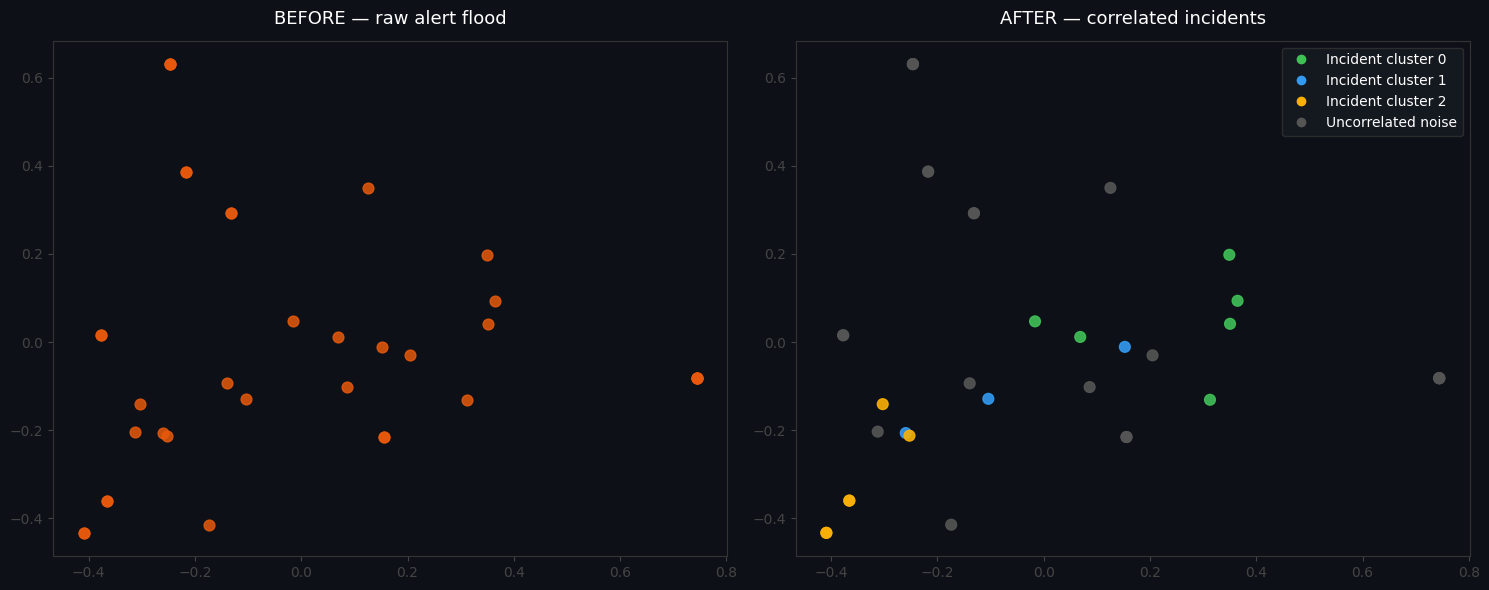

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

xy = PCA(n_components=2, random_state=0).fit_transform(embeddings)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#0d1117")

for ax, title in zip(axes, ["BEFORE — raw alert flood", "AFTER — correlated incidents"]):
    ax.set_facecolor("#0d1117")
    ax.set_title(title, color="white", fontsize=13, pad=12)
    ax.tick_params(colors="#444")
    for s in ax.spines.values():
        s.set_color("#333")

axes[0].scatter(xy[:, 0], xy[:, 1], c="#e8590c", s=60, alpha=0.85)

palette = ["#40c057", "#339af0", "#fab005", "#e64980", "#7950f2", "#15aabf"]
colors = ["#555555" if l == -1 else palette[l % len(palette)] for l in labels]
axes[1].scatter(xy[:, 0], xy[:, 1], c=colors, s=60, alpha=0.9)

handles = [Line2D([], [], marker="o", ls="", color=palette[l % len(palette)], label=f"Incident cluster {l}")
           for l in sorted(set(labels)) if l != -1]
handles.append(Line2D([], [], marker="o", ls="", color="#555555", label="Uncorrelated noise"))
axes[1].legend(handles=handles, facecolor="#161b22", labelcolor="white", edgecolor="#333")
plt.tight_layout()
plt.show()

## 6 · Measured evaluation (vs generator ground truth)
The generator labels every alert with the incident that produced it (or 'noise'). The pipeline never reads that field — so these numbers are real measurements across 8 random seeds, not cherry-picked claims.

In [7]:
EXPECT = {"db_connection_exhaustion": "INC-0389", "redis_memory_pressure": "INC-0412",
          "disk_full_logging": "INC-0367", "auth_cascade_failure": "INC-0401",
          "network_packet_loss": "INC-0355"}

tp_n = tp_d = dna_ok = dna_t = frag = missed = inc_total = noise_cl = noise_total = 0
for seed in [42, 7, 123, 2026, 555, 9, 77, 314]:
    u, _ = deduplicate(generate_batch(3, 20, 45, seed=seed))
    lab, _ = cluster_alerts(u, model)
    grp = group_by_label(u, lab)
    incidents = {a["ground_truth"] for a in u if a["ground_truth"] != "noise"}
    inc_total += len(incidents)
    noise_total += sum(1 for a in u if a["ground_truth"] == "noise")
    inc_map = {i: set() for i in incidents}
    for l, mem in grp.items():
        if l == -1:
            continue
        counts = pd.Series([a["ground_truth"] for a in mem]).value_counts()
        maj = counts.index[0]
        tp_n += counts.iloc[0]
        tp_d += len(mem)
        noise_cl += counts.get("noise", 0)
        for t in counts.index:
            if t != "noise":
                inc_map[t].add(l)
        if maj in EXPECT:
            dna_t += 1
            m = dna.match(mem)
            dna_ok += bool(m and m["incident_id"] == EXPECT[maj])
    frag += sum(max(0, len(v) - 1) for v in inc_map.values())
    missed += sum(1 for v in inc_map.values() if not v)

print(f"Across 8 seeds / {inc_total} synthetic incidents:")
print(f"  Incident detection:         {inc_total - missed}/{inc_total}  ({100*(inc_total-missed)/inc_total:.0f}%)")
print(f"  Cluster purity:             {100*tp_n/tp_d:.1f}%")
print(f"  Incident fragmentation:     {frag} events")
print(f"  Noise kept out of clusters: {100*(1 - noise_cl/noise_total):.1f}%")
print(f"  Alert DNA correct match:    {dna_ok}/{dna_t}  ({100*dna_ok/dna_t:.0f}%)")

Across 8 seeds / 24 synthetic incidents:
  Incident detection:         22/24  (92%)
  Cluster purity:             95.5%
  Incident fragmentation:     1 events
  Noise kept out of clusters: 91.6%
  Alert DNA correct match:    22/23  (96%)


## What is built vs. what is next

**Working today (this notebook + `backend/`):** synthetic multi-source alert generator · fingerprint dedup · embedding + time-windowed DBSCAN correlation · root-cause pick · Escalation Risk Score · Alert DNA matching · FastAPI ingest endpoint · measured evaluation harness.

**Next (by Jul 30):** Keep-inspired dark dashboard (Feed · Deduplication · Correlations · Incidents), live chaos→order animation, LLM-generated cluster summaries (interface already stubbed in `summarizer.py`), live never-seen-incident injection for the final demo.

**Datasets identified for further validation:** [Loghub](https://github.com/logpai/loghub) (HDFS/Linux/Apache logs), AIOps Challenge datasets.